In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt

G = 6.67 * 10 ** -11
M = 10 ** 35
c = 3 * 10 ** 8
D_s = 10 ** 21
D_d = 10**20
D_ds = 9*10**20

θ_E = np.sqrt((4*G*M)/(c**2)*D_ds/(D_d*D_s))

print(θ_E)

β_list = [[0,0], [0.5*θ_E,0.5*θ_E], [-θ_E,θ_E], [-2*θ_E,-2*θ_E]]

print(β_list)


1.6334013591276333e-06
[[0, 0], [8.167006795638167e-07, 8.167006795638167e-07], [-1.6334013591276333e-06, 1.6334013591276333e-06], [-3.2668027182552666e-06, -3.2668027182552666e-06]]


In [3]:
β = np.array(β_list[3])

β_mag = np.linalg.norm(β)

if β_mag != 0:
    factor_p = 0.5 * (1 + np.sqrt(1 + 4*θ_E**2 / β_mag**2))
    factor_n = 0.5 * (1 - np.sqrt(1 + 4*θ_E**2 / β_mag**2))
else:
    print('Einstein Ring')
    factor_p = 0
    factor_n = 0

θ_p = factor_p * β
θ_n = factor_n * β

print("β =", β)
print("θ+ =", θ_p)
print("θ- =", θ_n)

theta_p_mag = np.linalg.norm(θ_p)
theta_n_mag = np.linalg.norm(θ_n)

mu_p = (theta_p_mag / β_mag) * 1 / (1 + (θ_E**2 / theta_p_mag**2))
mu_n = (theta_n_mag / β_mag) * 1 / (1 + (θ_E**2 / theta_n_mag**2))

print("μ+ =", mu_p)
print("μ- =", mu_n)

β = [-3.26680272e-06 -3.26680272e-06]
θ+ = [-3.6339013e-06 -3.6339013e-06]
θ- = [3.67098578e-07 3.67098578e-07]
μ+ = 1.0103103630798287
μ- = 0.010310363079828754


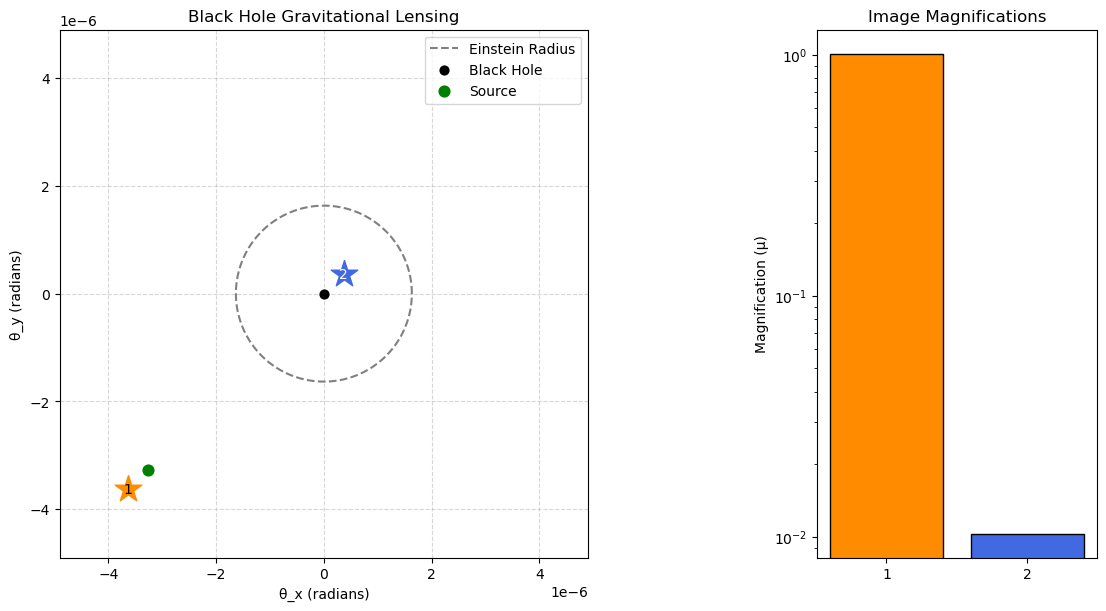

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Setup figure with subplots
# -----------------------------
fig, (ax, ax_bar) = plt.subplots(
    1, 2,
    figsize=(12, 6),
    gridspec_kw={'width_ratios': [3, 1]},
    constrained_layout=True
)

ax.set_aspect('equal')

# -----------------------------
# Colours
# -----------------------------
color_p = "darkorange"   # θ+
color_n = "royalblue"    # θ−

# -----------------------------
# Einstein radius circle
# -----------------------------
theta = np.linspace(0, 2*np.pi, 500)
x = θ_E * np.cos(theta)
y = θ_E * np.sin(theta)

ax.plot(x, y, label="Einstein Radius", color='gray', ls='--')

# -----------------------------
# Lens + source
# -----------------------------
ax.scatter(0, 0, color='black', s=40, label='Black Hole', zorder=5)
ax.scatter(*β, color='green', s=60, label='Source', zorder=5)

# -----------------------------
# Images (fixed size + numbering)
# -----------------------------
image_size = 400

mu_values = []
labels = []
colors = []

if β_mag < 1e-15:
    # Einstein ring case
    ax.plot(x, y, color='blue', label="Einstein Ring")

else:
    # θ+ image
    ax.scatter(θ_p[0], θ_p[1],
               marker='*',
               s=image_size,
               color=color_p)

    ax.text(θ_p[0], θ_p[1], "1",
            ha='center', va='center', color='black')

    # θ− image
    ax.scatter(θ_n[0], θ_n[1],
               marker='*',
               s=image_size,
               color=color_n)

    ax.text(θ_n[0], θ_n[1], "2",
            ha='center', va='center', color='white')

    # store for bar chart
    mu_values = [mu_p, mu_n]
    labels = ["1", "2"]
    colors = [color_p, color_n]

# -----------------------------
# Axis formatting
# -----------------------------
limit = 3 * θ_E

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

ax.grid(True, linestyle='--', alpha=0.5)

ax.set_xlabel("θ_x (radians)")
ax.set_ylabel("θ_y (radians)")
ax.set_title("Black Hole Gravitational Lensing")

ax.legend(loc='upper right')

# =====================================================
# BAR PLOT: Magnifications
# =====================================================

if len(mu_values) > 0:
    ax_bar.bar(labels, mu_values, color=colors, edgecolor='black')

    ax_bar.set_yscale('log')
    ax_bar.set_ylabel("Magnification (μ)")
    ax_bar.set_title("Image Magnifications")

else:
    ax_bar.text(0.5, 0.5, "Einstein Ring\n(no discrete images)",
                ha='center', va='center')
    ax_bar.set_axis_off()

# -----------------------------
# Final render
# -----------------------------
plt.show()
